# Exploratory Data Analysis

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


In [18]:
month_price = pd.read_csv('Nat_Gas.csv')

month_price.head(5)

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


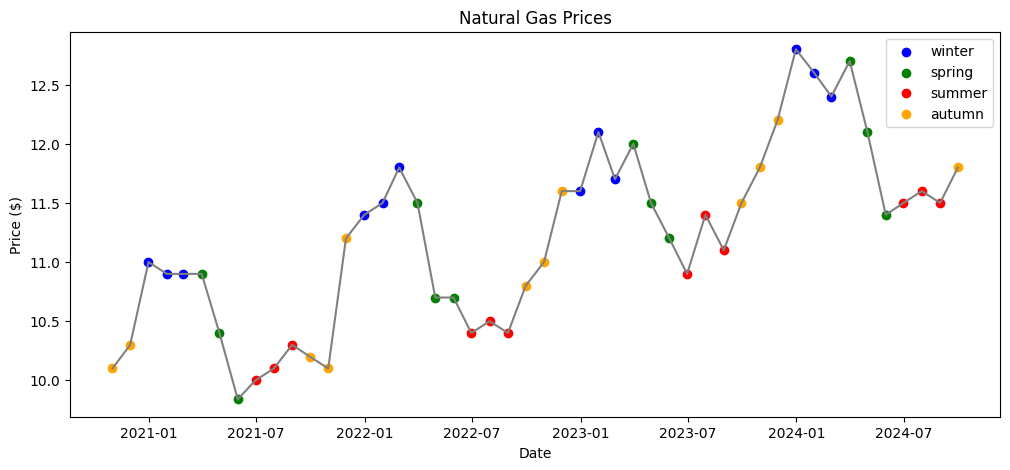

In [19]:
# Visualization

# Convert 'Dates' to datetime
# 'Dates' is in mm/dd/yy
month_price['Dates'] = pd.to_datetime(month_price['Dates'], format='%m/%d/%y')

# Add a 'Season' column in dataframe

# Define a mapping function
def season(m):
    if m in [12, 1, 2]:  return 'winter'
    if m in [3, 4, 5]:   return 'spring'
    if m in [6, 7, 8]:   return 'summer'
    if m in [9, 10, 11]: return 'autumn'

month_price['Season'] = month_price['Dates'].dt.month.map(season)

# Price plot
winter = month_price[month_price['Season'] == 'winter']
spring = month_price[month_price['Season'] == 'spring']
summer = month_price[month_price['Season'] == 'summer']
autumn = month_price[month_price['Season'] == 'autumn']

plt.figure(figsize=(12, 5))
plt.plot(month_price['Dates'], month_price['Prices'], '-', color='gray')

plt.scatter(winter['Dates'], winter['Prices'], color='blue',   label='winter')
plt.scatter(spring['Dates'], spring['Prices'], color='green',  label='spring')
plt.scatter(summer['Dates'], summer['Prices'], color='red',    label='summer')
plt.scatter(autumn['Dates'], autumn['Prices'], color='orange', label='autumn')

plt.title('Natural Gas Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# The date is showing the price at the start of the month
# Our data is the price at the end of each month

# Price Time Series Model

In [20]:
# Price Time Series Model

# price(t) = a + b*t + c*cos(2*pi*t/365.25 + d) + error
#          = a + b*t + c*cos(2*pi*t/365.25)*cos(d) - c*sin(2*pi*t/365.25)*sin(d) + error
#          = a + b*t + C*cos(2*pi*t/365.25) + D*sin(2*pi*t/365.25) + error

# Covert date to time t in days
t0  = month_price['Dates'].min()
t   = (month_price['Dates'] - t0).dt.days.to_numpy()
cost = np.cos(2 * np.pi * t / 365.25)
sint = np.sin(2 * np.pi * t / 365.25)

# Linear regression
y   = month_price['Prices'].to_numpy()
X = np.column_stack((np.ones_like(t), t, cost, sint))

# Ordinary Least Square Estimator
beta = np.linalg.inv(X.T @ X) @ X.T @ y
print('Coefficients:', beta)

# Predicted price
y_pred = X @ beta

Coefficients: [ 1.01312176e+01  1.50133642e-03 -2.62622729e-02  6.89271357e-01]


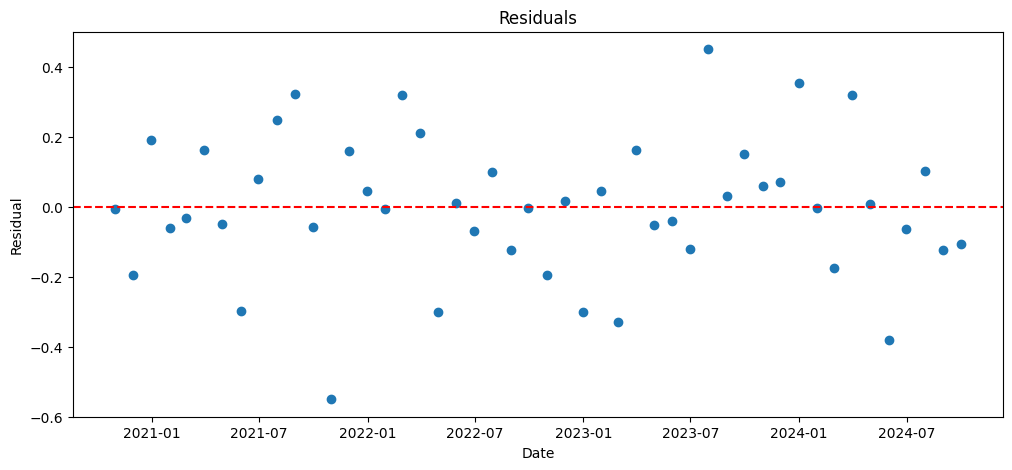

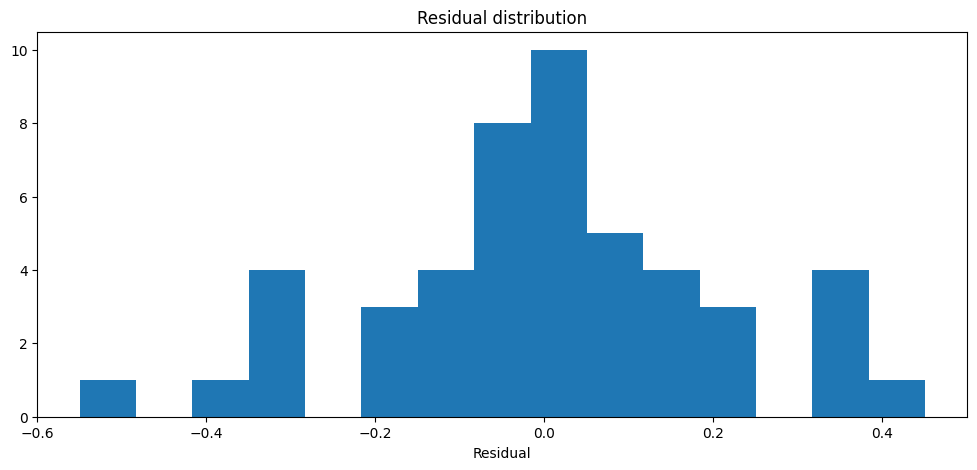

mean    = 0.0000
std     = 0.2008
W = 0.9839, p-value = 0.7462


In [21]:
# Residual Diagnostics

resid = y - y_pred

# Residual plot
plt.figure(figsize=(12, 5))
plt.scatter(month_price['Dates'], resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.show()

# Residual distribution
plt.figure(figsize=(12, 5))
plt.hist(resid, bins=15)
plt.title('Residual distribution')
plt.xlabel('Residual')
plt.show()

# Residual statistics
print(f"mean    = {resid.mean():.4f}")
print(f"std     = {resid.std():.4f}")

# Hypothesis testing
stat, p = stats.shapiro(resid)
print(f"W = {stat:.4f}, p-value = {p:.4f}")

# The null hypothesis: the residuals are normally distributed.
# We don't have a strong evidence to reject the null hypothesis

# Price Function

In [22]:
# Now we wrap the model into a function with a date as input.

t0  = month_price['Dates'].min()

def estimate_price(date):
    t = (pd.to_datetime(date) - t0).days
    cost = np.cos(2 * np.pi * t / 365.25)
    sint = np.sin(2 * np.pi * t / 365.25)
    X = np.array([1, t, cost, sint])
    price = X @ beta
    return price

# Fitted Price

In [23]:
# Fitted Price
history_dates = pd.date_range(start=month_price['Dates'].min(), end=month_price['Dates'].max(), freq='D')    
history_price = []
for date in history_dates:
    price = estimate_price(date)
    history_price.append(price)

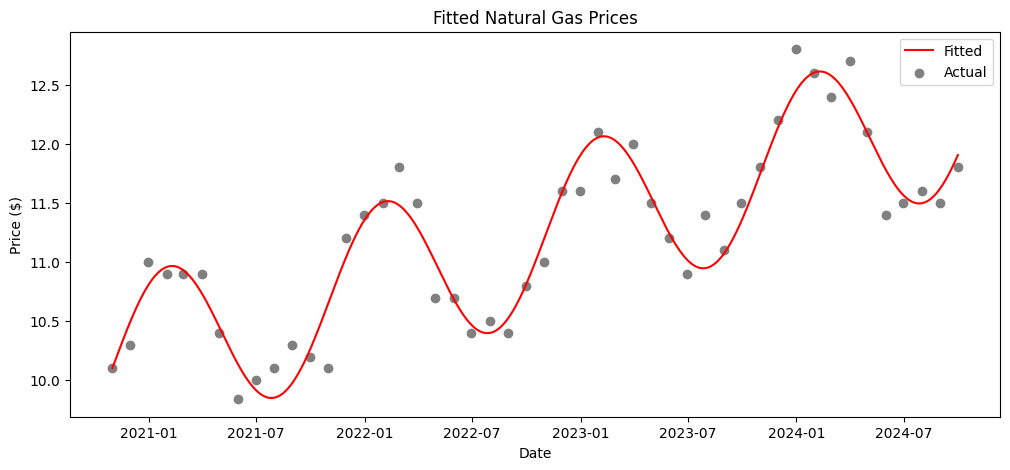

In [24]:
# Plot
plt.figure(figsize=(12, 5))
plt.plot(history_dates, history_price, color='red', label='Fitted')
plt.scatter(month_price['Dates'], month_price['Prices'], color='gray', label='Actual')

plt.title('Fitted Natural Gas Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# Extrapolation

In [25]:
# Price one year next
future_dates = pd.date_range(start=month_price['Dates'].max() + pd.Timedelta(days=1),
                             end=month_price['Dates'].max() + pd.DateOffset(years=1),
                             freq='D')
future_price = []
for date in future_dates:
    price = estimate_price(date)
    future_price.append(price)

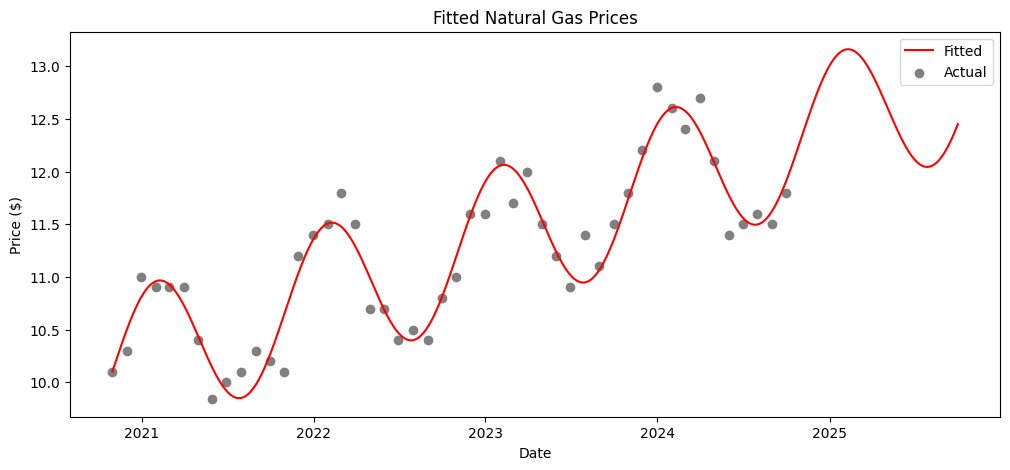

In [26]:
# Plot
all_dates = np.concatenate([history_dates, future_dates])
all_price = np.concatenate([history_price, future_price])

plt.figure(figsize=(12, 5))
plt.plot(all_dates, all_price, color='red', label='Fitted')
plt.scatter(month_price['Dates'], month_price['Prices'], color='gray', label='Actual')
plt.title('Fitted Natural Gas Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# Data

In [27]:
export_df = pd.DataFrame({'Dates': all_dates, 'Prices': all_price})
export_df.to_csv('Nat_Gas_Predicted.csv', index=False, float_format='%.6E')
